# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 1, February 25th, 2025

# 1) Binomial distribution

### Airline overbooking  

One in 20 passengers who have booked a flight does not show up at the boarding gate, without prior cancelling.
To maximise profit, airlines therefore sell more tickets than available seats (an expedient known as "overbooking"), knowing that, most of the times, they won't leave any passenger stranded and angry (and entitled to a refund or compensation). But, of course, airlines also accept the risk that, sometimes, this event will occur.  

1. calculate the probability that *at least one passenger* won't be given a seat, as a function of the aeroplane capacity (ranging from 50 to 300 seats) and of the number of tickets sold (>= capacity, cap it at maximum 25 extra tickets).

2. assuming that for each passenger left without a seat the airline loses twice the profit it makes on every ticket sold, compute how many tickets beyond capacity it can sell to make an extra profit and not lose money. Compute it first for a 300 seat aeroplane. Bonus: do it for any number of seats between 50 and 300.

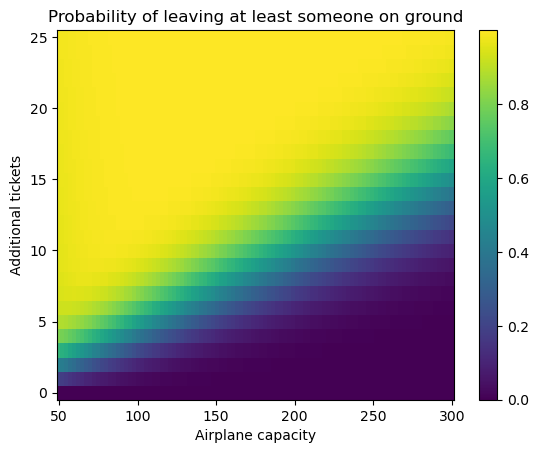

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math as m
from scipy.special import comb

#The probability that a passenger doesn't show up is
p = 1/20
seats = np.linspace(50,300,100)
overbook = np.linspace(0,25,26)

prob_grounded = np.zeros((np.size(seats),np.size(overbook)))
a = 0;
b = 0;
for n_seats in seats:
    for n_overbook in overbook:
        n = round(n_seats+n_overbook)
        #print(list(range(1,round(n_overbook)+1)))
        for budget in list(range(1,round(n_overbook)+1)): #budget is one of those number of passengers that don't allow to fit everyone in the plane: mininum is one, the maximum is the number of overbooked tickets (I have to add 1 because range doesn't include the limiting value)
            prob_grounded[a][b] += comb(n, budget, exact=True) * p**budget * (1-p)**(n-budget)
        #print(prob_grounded[a][b])
        b += 1
    b = 0
    a +=1

#print(prob_grounded)

#print(f"shape prob_grounded: {np.shape(prob_grounded)}\n shape seats: {np.shape(seats)}\n shape overbook: {np.shape(overbook)}")

xgrid, ygrid = np.meshgrid(seats, overbook)
plt.pcolor(xgrid, ygrid, prob_grounded.T)
plt.colorbar()
plt.xlabel("Airplane capacity")
plt.ylabel("Additional tickets")
plt.title("Probability of leaving at least someone on ground")
plt.show()

In [5]:
#The average number of people that do show up is (seats+overbook)*(1-p) . If this is smaller than seats we are fine: everyone has a seat.
#If this is greater than seats, (seats+overbook)*(1-p)-seats won't have a seat. Thus, the revenue is (seats+overbook)*price, but the loss
#is -2*[(seats+overbook)*(1-p)-seats]*price. As a consequence, the overall balance is
#              (seats+overbook)*price - 2*[(seats+overbook)*(1-p)-seats]*price
#When the balance becomes less than seats*price, is not convenient for the airline to bet on not-showing passengers: it'd better sell
#the actual number of seats. Price appears everywhere so it simplifies.

seats = 300;
p = 1/20;
for overbook in list(range(0,seats)):
    balance = (seats+overbook) - 2*((seats+overbook)*(1-p)-seats)
    if balance<seats:
        print(f"Maximum convenient number of overbooked tickets: {overbook-1}")
        break 

Maximum convenient number of overbooked tickets: 33


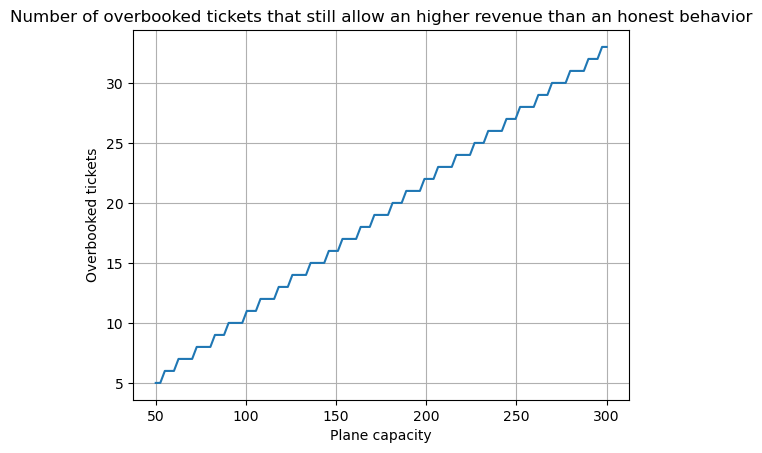

In [6]:
#Now, generalising to any number of seats from 50 to 300, 
seats = np.linspace(50,300,100)
p = 1/20
max_overbook = np.zeros(np.shape(seats))
index = 0
for n_seats in seats:
    n_seats=round(n_seats)
    for overbook in list(range(0,n_seats)):
        balance = (n_seats+overbook) - 2*((n_seats+overbook)*(1-p)-n_seats)
        if balance<n_seats:
            #print(f"Maximum convenient number of overbooked tickets for a plane with {n_seats} seats: {overbook-1}")
            max_overbook[index] = overbook-1
            break
    index += 1

plt.plot(seats, max_overbook)
plt.grid(1)
plt.xlabel("Plane capacity")
plt.ylabel("Overbooked tickets")
plt.title("Number of overbooked tickets that still allow an higher revenue than an honest behavior")
plt.show()

# 2) Poisson distribution

1. for a discrete random variable $x$ that follows the Poisson distribution $\mathcal{P}(x) = \frac{\mu^x}{x!}e^{-\mu}$, show that the parameter $\mu$ represents both the means and the variance
3. a particle detector used to measure the activity of a radioactive source has a dead time of 1 $\mu s$. That is, after a particle has been recorded by the detector, the detector remains blind and unable to detect other particle for a duration of 1 $\mu s$. Plot the probability that a particle impinging on the detector after a positive count would end up in a dead time window (and not be detected) as a function of the incoming flux particle/second.
4. The detector measure a count rate of 0.3 MHz. Compute the actual flux of the radioactive source, considering the detector efficiency of 60% and a deadtime of 1 $\mu s$

**Point 1**  
The mean of the Poissonian distribution is obtained as 

$\sum_{x=0}^{+\infty} \mathcal{P}(x)x =\sum_{x=1}^{+\infty} \mathcal{P}(x)x = \sum_{x=1}^{+\infty} \mu \frac{\mu^{x-1}}{(x-1)!}e^{-\mu} = \mu \sum_{x=1}^{+\infty} \mathcal{P}(x-1)$ 

but at this point a simple change of variable is enough to prove that the sum equals one, following directly from the normalization condition of the probability distribution. As a direct consequene, $E[x]=\mu$. Similarly, we can determine the expectation value of $x^2$ as

$\sum_{x=0}^{+\infty} \mathcal{P}(x)x^2 = \sum_{x=1}^{+\infty} \mu \frac{\mu^{x-1}}{(x-1)!}e^{-\mu}x = \mu \sum_{x=1}^{+\infty} \mathcal{P}(x-1)x$ 

then, changing variable $y=x-1$, we get 

$E[x^2] = \mu \sum_{y=o}^{+\infty} \mathcal{P}(y)(y+1)=\mu(E[x]+1)=\mu^2+\mu$. 

The resulting variance is $Var(x)=E[x^2]-E[x]^2=\mu$

**Point 2**  
For a given flux $\phi$, the average number of incoming particles within the dead time is $\phi\times 1\mu$s. Since we don't know the number of particles that can, theoretically, impinge on the detector but we believe this number to be very large, we can assume that the number of incoming particles within the dead time is Poissonian distributed with parameter $\lambda=\phi\times 1\mu$s. As a consequence, the probability of not having any particle at all is  
$P(0)=e^{-\lambda}$  
so the probability that *at least* one particle reaches the detector during its dead time is  
$P(\geq 1) = 1-e^{-\lambda}=1-e^{-\phi\times 1\mu s}$

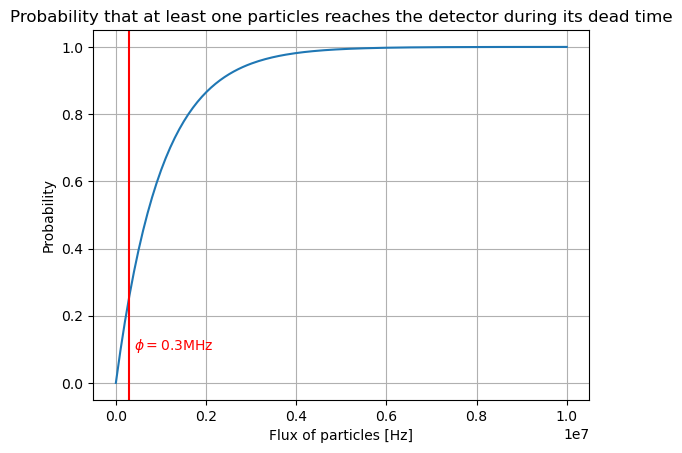

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import math as m

phi = np.linspace(0,1e7,200)
prob = np.zeros(np.shape(phi))
i = 0;
while i<np.size(phi):
    prob[i] = 1 - m.exp(-phi[i]*1e-6)
    i+=1

plt.plot(phi,prob)
plt.grid(1)
plt.xlabel("Flux of particles [Hz]")
plt.ylabel("Probability")
plt.title("Probability that at least one particles reaches the detector during its dead time")
plt.axvline(3e5,color="r")
plt.text(4e5,0.1,"$\\phi=0.3$MHz",color="r") #weird, but it seems like I have to use two backslash to plot it correctly
plt.show()

**Point 3**  
We have to account for the particles that have impinged on the detector during its dead time and for a finite efficiency. First, let's start assuming 100% efficiency, later I will factor in the actual value.  
The value of the flux has to be corrected, but it won't fall too far from the real value. Thus, taking it as a reference for the moment, we see from the previous graph that $\phi=0.3$MHz$=3e5$Hz corresponds to a "missed detection" probability of around 0.3 and the corresponding parameter of a Poissonian distribution is $\lambda=0.3$. For this value, the probability of having two incoming particles within the dead time is  
$P(2)=\frac{\lambda^2}{2}e^{-\lambda}$

In [8]:
lam = 0.3
P1=lam*m.exp(-lam)
P2=lam**2/2*m.exp(-lam)
print(f"P(1)={P1}, P(2)={P2}")

P(1)=0.22224546620451535, P(2)=0.0333368199306773


Since the probability is equal to 3%, I will neglect it for simplicity (and also the probabilities of missing any higher number of particles). As we see from P(1), the probability that a particle goes undetected is roughly 22%. Thus, if the detector counts N particles in a time window $\Delta t\gg1$, the actual number of particles is N+P(1)*N, because for each successful detection event there's a P(1) chance that another particles is missed. As a consequence, the flux has to be corrected as follows  
$\phi'=\frac{N(1+P(1))}{\Delta t} = \phi(1+P(1))$

In [9]:
phi=3e5
new_phi=phi*(1+P1)
print(f"Flux corrected for missed counts: phi'={new_phi}")

Flux corrected for missed counts: phi'=366673.63986135466


If one wanted to be a bit more precise, and factor in also the probability of two missed particles, they should add to the count of particles also $2*N*P(2)$, resulting in a correction to the flux equal to $\phi(1+P(1)+2P(2))$ and a new value of

In [10]:
new_phi=phi*(1+P1+2*P2)
print(f"Flux corrected for missed counts: phi'={new_phi}")

Flux corrected for missed counts: phi'=386675.731819761


At this point we can also factor in the missed count up to an arbitrary number, over which we consider the probability of having so many undetected particles negligible. I arbitrarily set this limit to 50.  
Actually, one can notice that the terms we are adding are the definition of the expectation value of the Poissonian distribution. So the exact correction to the measured flux is simply  
$\phi'=\phi(1+\lambda)$

In [15]:
new_phi=phi*(1+lam)
print(f"Flux corrected for missed counts: phi'={new_phi}")

Flux corrected for missed counts: phi'=390000.0


So considering only one missed particle would actually have been a huge over-simplification.  

Now we can move on and consider a finite detection efficiency, namely 60%. This means that the measured total number of successful counts is only 60% of the actual value. Note, though, that the limited detection efficiency doesn't affect at all the number of missed particles due to the dead time. So this correction shall only affect the first term in the parenthesis  
$\phi'=\phi(1+\lambda) \longrightarrow \phi(\frac{100}{60}+\lambda)$

In [19]:
final_phi=phi*(10/6+lam)
print(f"Final corrected flux of incoming particles, factoring in both a finite detection efficiency and a dead time of 1e-6 s: {final_phi}")

Final corrected flux of incoming particles, factoring in both a finite detection efficiency and a dead time of 1e-6 s: 590000.0


# 3) Central Limit Theorem (CLT)

For an excellent animated explanation, watch this video
https://www.youtube.com/watch?v=zeJD6dqJ5lo

1. An experiment consists of rolling 5 dice and then noting down the sum of the 5 outcomes.
   Repeat the experiment 1, 10, 100, 1000, and 10000 times and for each number of repetitions, plot the obtained sum of outcomes in an histogram. Superimpose to each histogram the normal distribution with mean and width parameters predicted by the central limit theorem
3. for this variation, use unfair dice, that is the probability of their outcomes isn't 1/6 for each of the 6 digits, but [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] for [1, 2, 3, 4, 5, 6] respectively. Start with rolling 10 dice up to 100000 repetitions
2. with the same unfair dice, roll only 2 dice, again for up to 100000 repetitions. Does CLT work?
3. now roll 6 *different* unfair dice, for each dice use a permutation of the distribution given above [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] (no repetitions). Does CLT work?

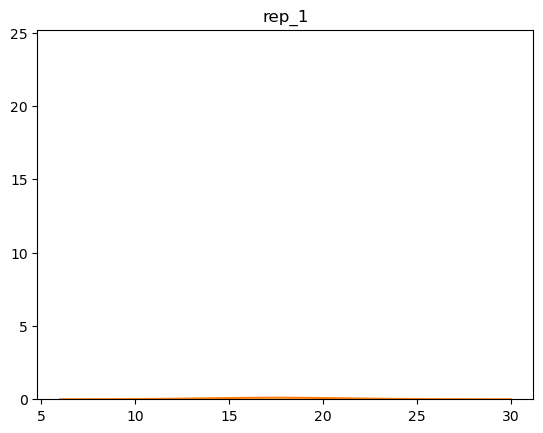

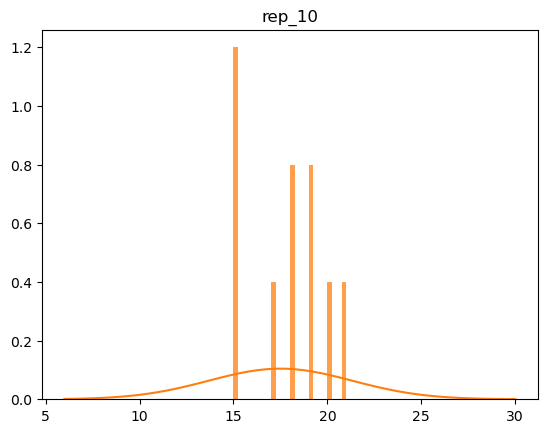

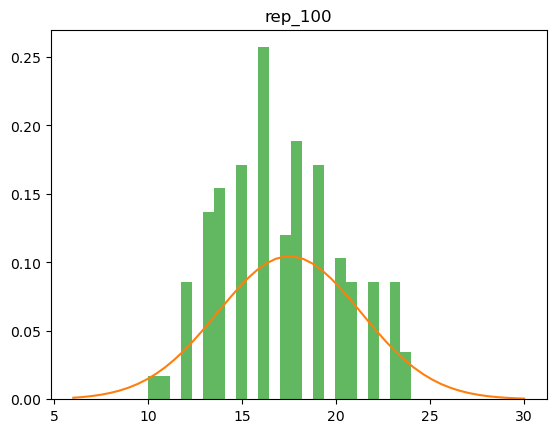

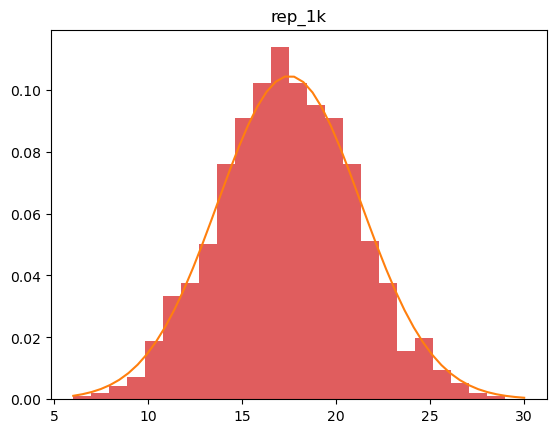

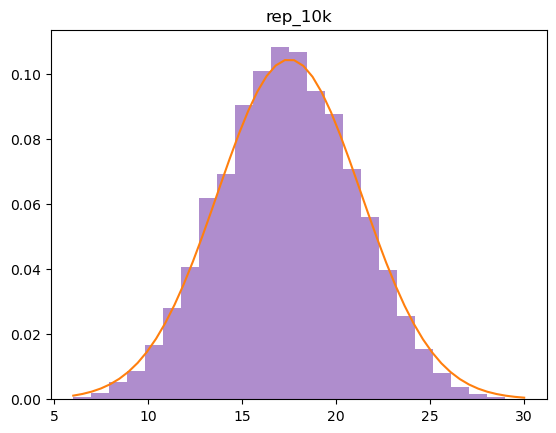

In [14]:
# POINT 1
# Assuming the dice are fair, the outcomes are uniformly distributed.
import numpy as np
import matplotlib.pyplot as plt
import math as m
N = 5
np.random.seed(1235897)

rep_1 = np.zeros(1) #Array containing the sum of the N dices over 1 repetition
rep_10 = np.zeros(10)
rep_100 = np.zeros(100)
rep_1k = np.zeros(1000)
rep_10k = np.zeros(10000)
rep = {"rep_1":rep_1,"rep_10":rep_10,"rep_100":rep_100,"rep_1k":rep_1k,"rep_10k":rep_10k}
colour = {"rep_1":"#1F77B4","rep_10":"#FF7F0E","rep_100":"#2CA02C","rep_1k":"#D62728","rep_10k":"#9467BD"}

for name,variable in rep.items():
    l=0
    while l<np.size(variable):
        i=0
        while i<N:
            variable[l] += np.random.randint(1,7) #apparently the higher extreme is excluded
            i+=1
        l+=1

mu = 3.5 #mean of a uniform distribution of single-fair-dice outcomes
var = 0; i=1
while i<7: var+=i**2/6; i+=1;
var = var-mu**2 #variance of the same random variable

x = np.linspace(N,N*6)
y = np.zeros(np.size(x))
for name, variable in rep.items():
    plt.hist(variable, 24, density=1, facecolor=colour[name], alpha=0.75, ec="black")
    plt.title(name)
    i = 0
    while i<np.size(x):
        y[i] = 1/m.sqrt(2*m.pi)/m.sqrt(N*var)*m.exp(-1/2*(x[i]-N*mu)**2/N/var)
        i += 1
    plt.plot(x,y)
    plt.show()

#I'm concerned with the results of rep_100... there are some values that are never taken. On the one hand, 100 is not that high to get all the 24 possible outcomes, but on the other hand it still looks weird

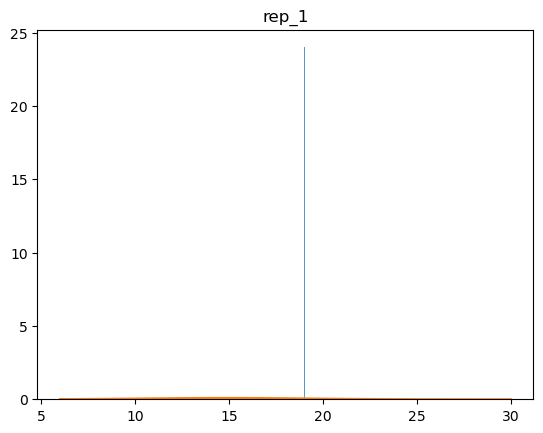

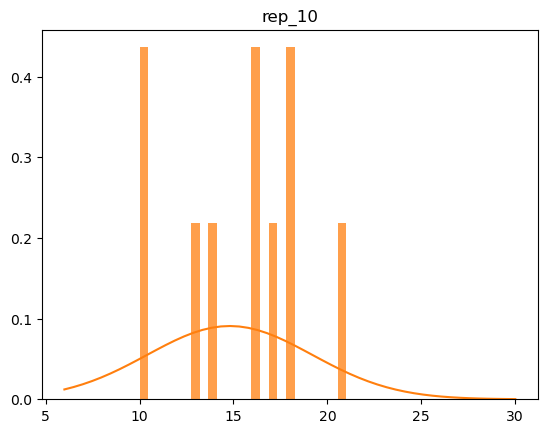

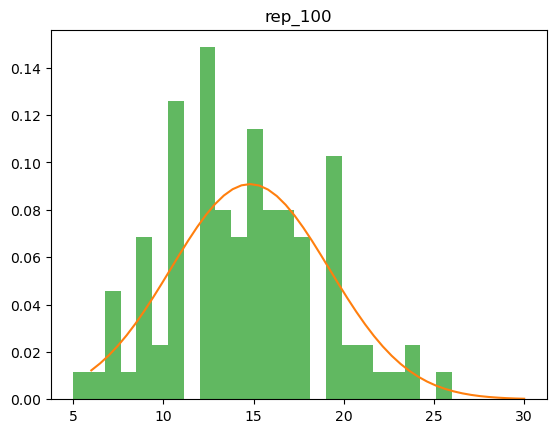

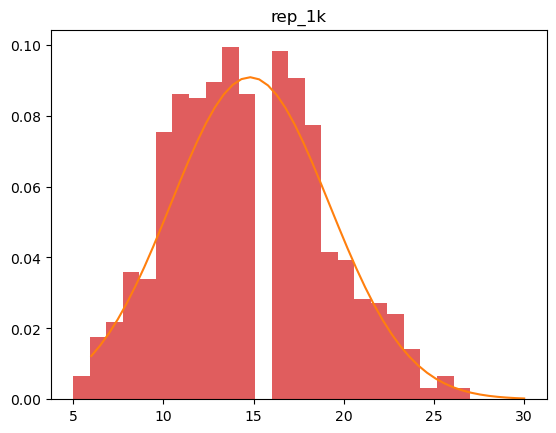

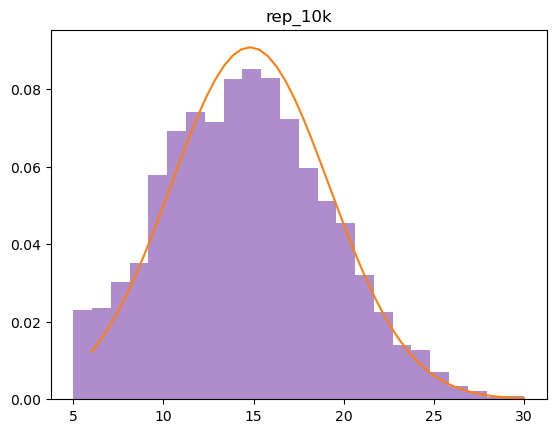

In [41]:
# POINT 2
import numpy as np
import matplotlib.pyplot as plt
import math as m
N = 5
np.random.seed(1235897)

rep_1 = np.zeros(1) #Array containing the sum of the N dices over 1 repetition
rep_10 = np.zeros(10)
rep_100 = np.zeros(100)
rep_1k = np.zeros(1000)
rep_10k = np.zeros(10000)
rep = {"rep_1":rep_1,"rep_10":rep_10,"rep_100":rep_100,"rep_1k":rep_1k,"rep_10k":rep_10k}
colour = {"rep_1":"#1F77B4","rep_10":"#FF7F0E","rep_100":"#2CA02C","rep_1k":"#D62728","rep_10k":"#9467BD"}

#I can simulate the distribution [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] creating an array of 100 outcomes, out of which 37 are 1, 16 are 2... and then uniformly extract an index of such an array. The ordering inside the array shouldn't matter as long as the index is tryly random
outcomes = np.zeros(100)
unfairness = {"1":(1,37),"2":(2,16),"3":(3,10),"4":(4,7),"5":(5,11),"6":(6,19)} #the first element of the tuple is the outcome, the second is the probability*100
i = 0
for name, element in unfairness.items():
    l = 0
    while l<element[1]:
        outcomes[i] = element[0]
        #print(type(element[0]))
        i += 1
        l += 1
#print(outcomes)

#Now I can move on to the actual simulation
for name,variable in rep.items():
    l=0
    while l<np.size(variable):
        i=0
        while i<N:
            index = np.random.randint(0,np.size(outcomes))
            variable[l] += outcomes[index]
            i+=1
        l+=1
    #print(variable)

#Now I can plot the results in the same way as before
mu = 0; i=0
while i<np.size(outcomes):
    mu += outcomes[i]/np.size(outcomes)
    i += 1
#print(mu)
var = 0; i=0
while i<np.size(outcomes):
    var += outcomes[i]**2/np.size(outcomes)
    i += 1
var = var-mu**2
#print(var)

x = np.linspace(N,N*6)
y = np.zeros(np.size(x))
for name, variable in rep.items():
    plt.hist(variable, 24, density=1, facecolor=colour[name], alpha=0.75, ec="black")
    plt.title(name)
    i = 0
    while i<np.size(x):
        y[i] = 1/m.sqrt(2*m.pi)/m.sqrt(N*var)*m.exp(-1/2*(x[i]-N*mu)**2/N/var)
        i += 1
    plt.plot(x,y)
    plt.show()

#Similarly to point 1, the absence of any outcome 16 with 1k repetitions looks very weird


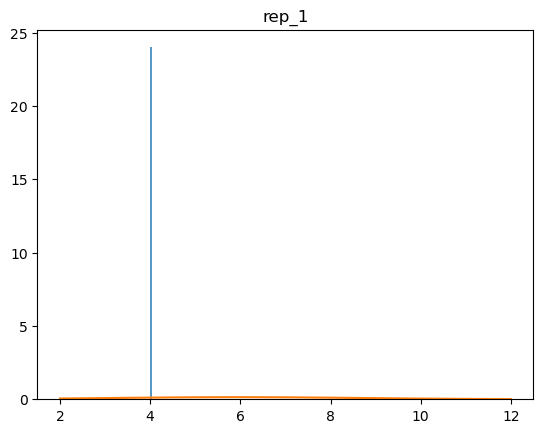

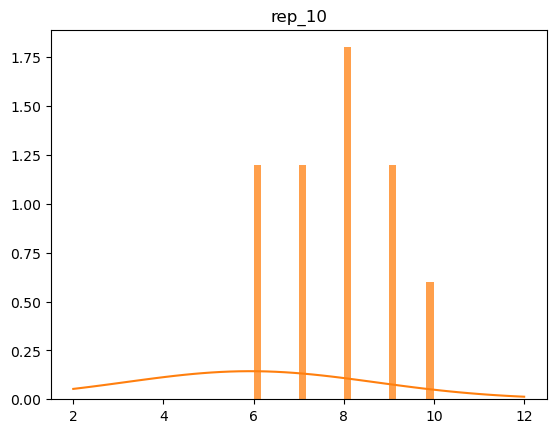

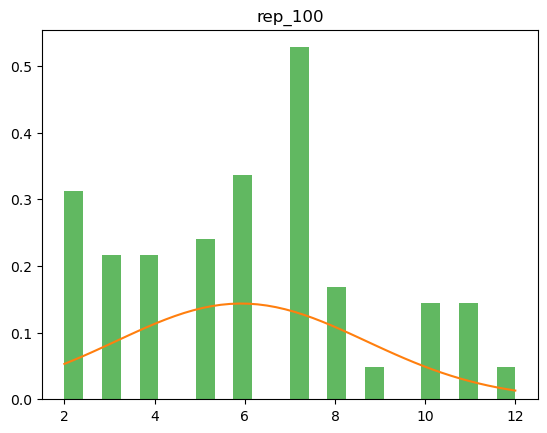

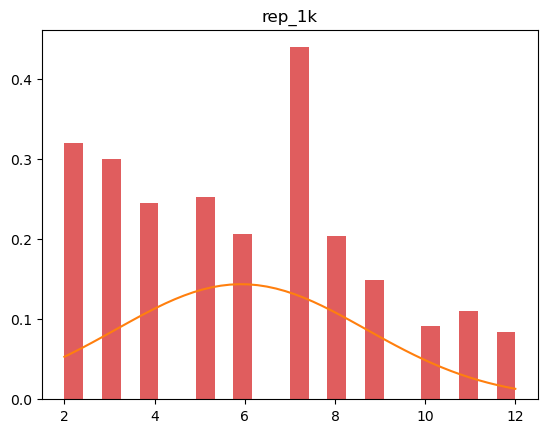

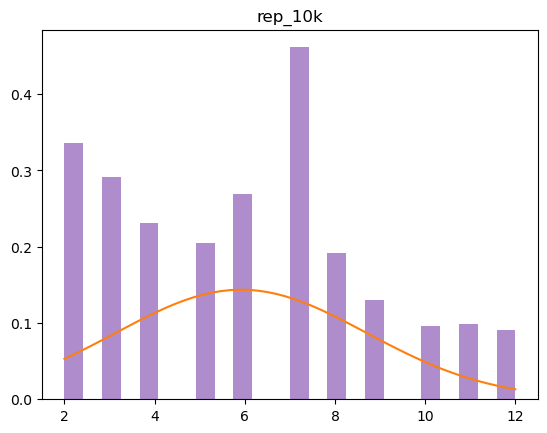

In [44]:
# POINT 3
import numpy as np
import matplotlib.pyplot as plt
import math as m
N = 2
np.random.seed(1235897)

rep_1 = np.zeros(1) #Array containing the sum of the N dices over 1 repetition
rep_10 = np.zeros(10)
rep_100 = np.zeros(100)
rep_1k = np.zeros(1000)
rep_10k = np.zeros(10000)
rep = {"rep_1":rep_1,"rep_10":rep_10,"rep_100":rep_100,"rep_1k":rep_1k,"rep_10k":rep_10k}
colour = {"rep_1":"#1F77B4","rep_10":"#FF7F0E","rep_100":"#2CA02C","rep_1k":"#D62728","rep_10k":"#9467BD"}

#I can simulate the distribution [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] creating an array of 100 outcomes, out of which 37 are 1, 16 are 2... and then uniformly extract an index of such an array. The ordering inside the array shouldn't matter as long as the index is tryly random
outcomes = np.zeros(100)
unfairness = {"1":(1,37),"2":(2,16),"3":(3,10),"4":(4,7),"5":(5,11),"6":(6,19)} #the first element of the tuple is the outcome, the second is the probability*100
i = 0
for name, element in unfairness.items():
    l = 0
    while l<element[1]:
        outcomes[i] = element[0]
        #print(type(element[0]))
        i += 1
        l += 1
#print(outcomes)

#Now I can move on to the actual simulation
for name,variable in rep.items():
    l=0
    while l<np.size(variable):
        i=0
        while i<N:
            index = np.random.randint(0,np.size(outcomes))
            variable[l] += outcomes[index]
            i+=1
        l+=1
    #print(variable)

#Now I can plot the results in the same way as before
mu = 0; i=0
while i<np.size(outcomes):
    mu += outcomes[i]/np.size(outcomes)
    i += 1
#print(mu)
var = 0; i=0
while i<np.size(outcomes):
    var += outcomes[i]**2/np.size(outcomes)
    i += 1
var = var-mu**2
#print(var)

x = np.linspace(N,N*6)
y = np.zeros(np.size(x))
for name, variable in rep.items():
    plt.hist(variable, 24, density=1, facecolor=colour[name], alpha=0.75, ec="black")
    plt.title(name)
    i = 0
    while i<np.size(x):
        y[i] = 1/m.sqrt(2*m.pi)/m.sqrt(N*var)*m.exp(-1/2*(x[i]-N*mu)**2/N/var)
        i += 1
    plt.plot(x,y)
    plt.show()

#Rolling two dices only the distribution doesn't get close to the normal distribution at all


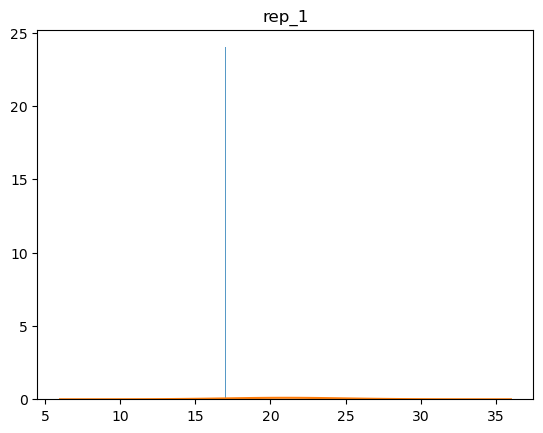

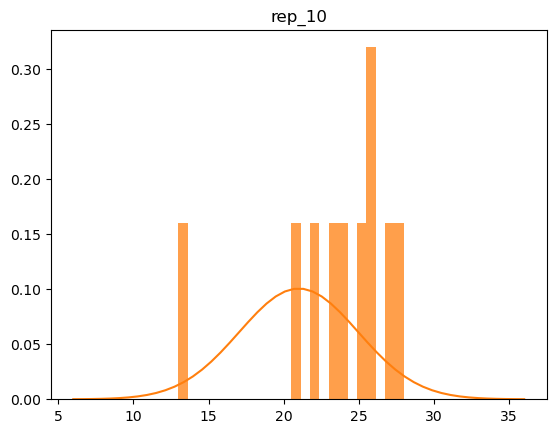

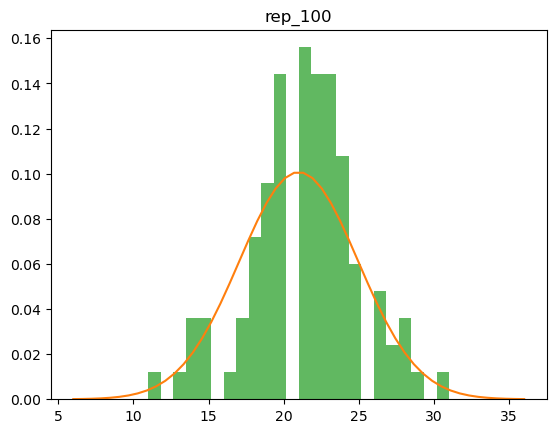

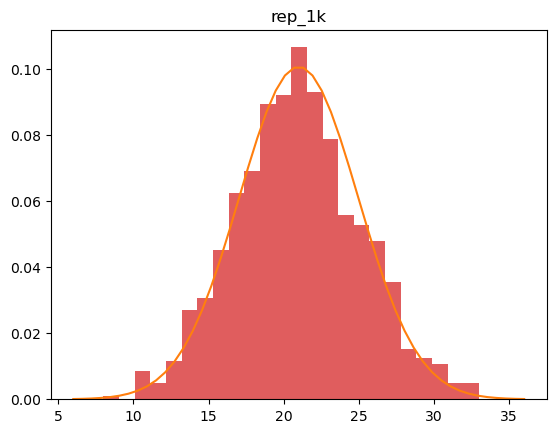

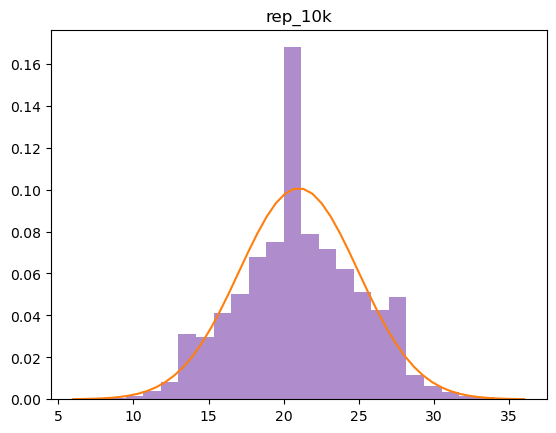

In [18]:
# POINT 4
import numpy as np
import matplotlib.pyplot as plt
import math
N = 6
np.random.seed(1235897)

rep_1 = np.zeros(1) #Array containing the sum of the N dices over 1 repetition
rep_10 = np.zeros(10)
rep_100 = np.zeros(100)
rep_1k = np.zeros(1000)
rep_10k = np.zeros(10000)
rep = {"rep_1":rep_1,"rep_10":rep_10,"rep_100":rep_100,"rep_1k":rep_1k,"rep_10k":rep_10k}
colour = {"rep_1":"#1F77B4","rep_10":"#FF7F0E","rep_100":"#2CA02C","rep_1k":"#D62728","rep_10k":"#9467BD"}

#I can simulate the distribution [0.37, 0.16, 0.10, 0.07, 0.11, 0.19] creating an array of 100 outcomes, out of which 37 are 1, 16 are 2... and then uniformly extract an index of such an array. The ordering inside the array shouldn't matter as long as the index is tryly random
unfairness_1 = {"1":(1,37),"2":(2,16),"3":(3,10),"4":(4,7),"5":(5,11),"6":(6,19)}
unfairness_2 = {"2":(2,37),"3":(3,16),"4":(4,10),"5":(5,7),"6":(6,11),"1":(1,19)}
unfairness_3 = {"3":(3,37),"4":(4,16),"5":(5,10),"6":(6,7),"1":(1,11),"2":(2,19)}
unfairness_4 = {"4":(4,37),"5":(5,16),"6":(6,10),"1":(1,7),"2":(2,11),"3":(3,19)}
unfairness_5 = {"5":(5,37),"6":(6,16),"1":(1,10),"2":(2,7),"3":(3,11),"4":(4,19)}
unfairness_6 = {"6":(6,37),"1":(1,16),"2":(2,10),"3":(3,7),"4":(4,11),"5":(5,19)}
dictionary_of_unfairness = {"First dice":unfairness_1,"Second dice":unfairness_2,"Third dice":unfairness_3,"Fourth dice":unfairness_4,"Fifth dice":unfairness_5,"Sixth dice":unfairness_6}
outcomes = np.zeros((6,100)) #each element of the outer layer is the array of outcomes of the corresponding dice. Even though the outcomes are sorted in a different order, by the randomness of the index this should not be a problem
#print(np.shape(outcomes))
m = 0
for name,unfair in dictionary_of_unfairness.items():
    i = 0
    for name, element in unfair.items():
        l = 0
        while l<element[1]:
            outcomes[m][i] = element[0]
            #print(type(element[0]))
            i += 1
            l += 1
    m += 1
#print(outcomes[3][0])
_,outcomes_length = np.shape(outcomes)
#print(outcomes_length)

#Now I can move on to the actual simulation
for name,variable in rep.items():
    l=0
    while l<np.size(variable):
        m=0
        while m<N:
            index = np.random.randint(0,outcomes_length)
            variable[l] += outcomes[m][index]
            m+=1
        l+=1
    #print(variable)

#Now I can plot the results in the same way as before
mu = np.zeros(N)
m = 0
while m<N:
    i = 0
    while i<outcomes_length:
        mu[m] += outcomes[m][i]/outcomes_length
        i += 1
    #print(mu[m])
    m += 1
var = np.zeros(N)
m = 0
while m<N:
    i = 0
    while i<outcomes_length:
        var[m] += outcomes[m][i]**2/outcomes_length
        i += 1
    var[m] = var[m] - mu[m]**2
    #print(var[m])
    m += 1

i = 0
mu_sum = 0
var_sum = 0
while i<N:
    mu_sum += mu[i]
    var_sum += var[i]
    i += 1
#print(f"Mean of the sum of the {N} dices: {mu_sum}")
#print(f"Variance of the sum of the {N} dices: {var_sum}")

x = np.linspace(N,N*6)
y = np.zeros(np.size(x))
for name, variable in rep.items():
    plt.hist(variable, 24, density=1, facecolor=colour[name], alpha=0.75, ec="black")
    plt.title(name)
    i = 0
    while i<np.size(x):
        y[i] = 1/math.sqrt(2*math.pi)/math.sqrt(var_sum)*math.exp(-1/2*(x[i]-mu_sum)**2/var_sum)
        i += 1
    plt.plot(x,y)
    plt.show()

#With the seed 1235897 there's a super-strange spike in the graph of 10k repetitions, but nothing strange appears in 1k, which is well approximated by a gaussian. Some strange behaviour remain even for other seeds: there are some spikes that greatly differ from a gaussian behavior.
#I will leave the original seed, the same of previous points, so that you can see in the last graph the problem I'm referring to
#The issue doesn't disappear increasing the number of repetitions. I shall try to increase the number of dices if I have time

# 4) Summary statistics

IMPORT SCIKIT FIRST for function make_moons

In [12]:
def generate_dataset(N, seed=42):
    np.random.seed(seed)
    # Define mean vector (center of the distribution)
    mean = [1, -0.5, 1.2]
    # Define covariance matrix (controls relationships between features)
    cov = [
        [3,     -0.8,  1.2],
        [-0.8,  1.5,   0.5],
        [1.2,   0.5,   2]
    ]
    # Sample N points from the multivariate normal distribution
    X = np.random.multivariate_normal(mean, cov, size=N)
    X2, Y = make_moons(n_samples=N, noise=0.05, random_state=seed)
    X3 = np.random.poisson(1, size=N) #+ np.random.normal(0, 0.3, size=N)
    
    data = np.concatenate([X, X2, X3[:,None]], axis=1)
    return data

In [13]:
N = 10000
X = generate_dataset(N, seed=42)

# for convenience, convert into pandas dataframe to have named columns
import pandas as pd
columns = ["temperature", "pression", "position", "speed", "acceleration", "number_of_particles"]
X = pd.DataFrame(X, columns=columns)

NameError: name 'make_moons' is not defined

You have a dataset consisting of multiple observations of 6 quantities, measured in a lab experiment: temperature, pression, position, speed, acceleration, number of particles.

- Each "row" in the dataset corresponds to a different observation.
- Each "column" in the dataset corresponds to a different features or measurement of your observation.

**Your goal for this exercise is to compute the summary statistics for each of the quantities measured in the experiment**:
- How the features are distributed?
    - Compute the mean and the standard deviation of each feature, first "by hand", then try with python libraries methods.
    - Compute the median and the mode of the distributions first "by hand", then try with python libraries methods.
    - Compute the quantiles of each feature
      
- How they are correlated? Compute the covariance matrix of the features and the correlation, first "by hand", then try with python libraries methods.
- Compute higher order momenta of the distributions.
- Before doing any histogram, how do you expect the numbers are distributed? Do you think they are gaussian or having a different distribution?  (_don't look too close to the dataset generating code_ ;) )

- plot each feature in histograms

### Histograms

Histograms are tools to estimate a probability density function when samples or "observations" are available. 
In this next part of the exercise you will analyze the dataset by plotting histograms of each measurement feature and also by checking their corrections with 2D histograms.

1) Draw the 1D histogram of all the features in the dataset
2) Draw the 2D histograms of pairs of features.
3) (Bonus) You can  plot then as a "corner" plot, look [here](https://corner.readthedocs.io/en/latest/pages/quickstart/) to take inspiration.